In [1]:
import numpy as np
import pandas as pd
import hist
from hist import Hist
import awkward as ak
import json
import uproot
import math
from coffea import util

import matplotlib.pyplot as plt
import mplhep
plt.style.use(mplhep.style.CMS)

In [2]:
out_dir = "../outfiles/Run3Summer22EE"

output = util.load(f"../outfiles/Run3Summer22EE/ddt/dask_QCD.coffea")[0]

# Table of contents

* [Create DDT map](#create)
* [Using the DDT map](#use)

# Create the DDT map <a class="anchor" id="create"></a>

In [3]:
# 3D hist
# bin: (rho, pt, n2b1)
# value: number of jets
ddthist = output['h'][{'dataset' : sum}]

val_QCD = ddthist.values()
var_QCD = ddthist.variances()

# 3D array
# bin: (rho, pt, n2b1)
# value: cumulative sum of number of jets
qcd_maxval_temp = np.cumsum(val_QCD, axis=2)

# 2D array
# bin: (rho, pt)
# value: total cumulative sum of number of jets
qcd_maxval = qcd_maxval_temp[:, :, -1]

# 3D array
# bin: (rho, pt, n2b1)
# value: number of jets divided by total cumulative sum, i.e. an efficiency
norma = qcd_maxval_temp / np.maximum(1e-10, qcd_maxval[:, :, np.newaxis])

from copy import copy, deepcopy
hist_y_QCD = deepcopy(ddthist)
# template = hist_y_QCD[{"n2b1" : sum}]
template = Hist(
    hist.axis.Regular(100, -8, -0.5, name="rho", label=r"$\rho=ln(m^2_{reg}/p_T^2)$"),
    hist.axis.Regular(100, 250, 1350, name="pt", label=r"$p_T$ (GeV)"),
)

# 3D hist
# bin: (rho, pt, n2b1)
# value: number of jets divided by total cumulative sum
hist_y_QCD[:, :, :] = norma
# hist_y_QCD[:, :, :] = np.append(norma[:, :, :, np.newaxis], var_QCD[:, :, :, np.newaxis], axis=3)

In [4]:
# find the index of 26% efficiency in norma
eff=0.26
res = np.apply_along_axis(lambda norma: norma.searchsorted(eff), axis = 2, arr = norma)
res[res>1000]=0

# find the n2b1 value that corresponds to the index
def bineval(a):
    return hist_y_QCD.project("n2b1").axes[0].edges[a]

binfunc = np.vectorize(bineval)
qmap = binfunc(res)
qmap[qmap == -math.inf] = 0

template[:, :] = qmap
# var_temp = template.variances()
# template[:, :] = np.append(qmap[:, :, np.newaxis], var_temp[:, :, np.newaxis], axis=2)

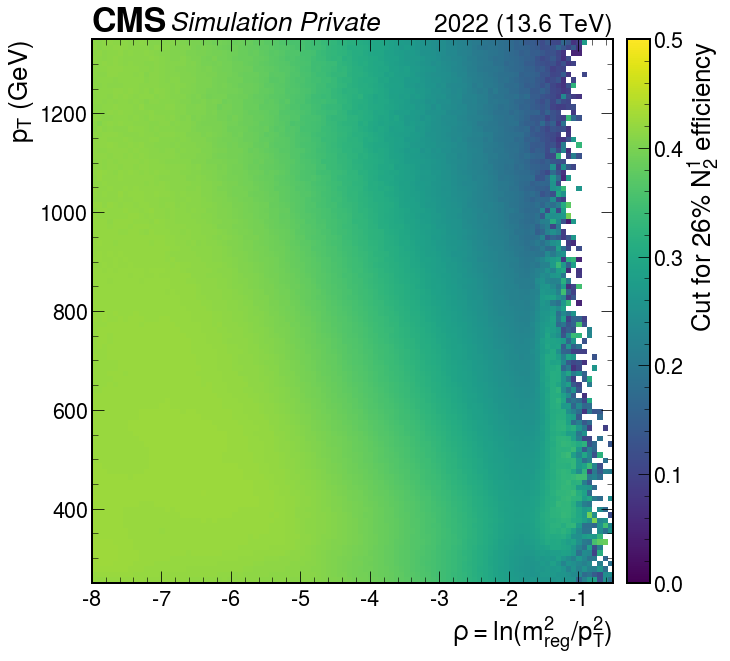

In [6]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.style.use(mplhep.style.CMS)

label = mplhep.cms.label(ax=ax, data=False, year="2022", com=13.6, label="Private")
_, c, _ = mplhep.hist2dplot(template.project("rho", "pt"), cmin=0, cmax=0.5, cbarsize="4%")
ylabel = c.set_label(r"Cut for 26% $N_2^1$ efficiency")

## Using the DDT map <a class="anchor" id="use"></a>

In [7]:
from coffea.lookup_tools.dense_lookup import dense_lookup

lookup = dense_lookup(template.view(), (template.axes[0].edges, template.axes[1].edges))

In [8]:
# Example: FatJet.rho = -3.4 and FatJet.pt = 500

lookup(-3.4, 730)

0.322

In [10]:
import pickle

picklename = f"../data/n2b1/ddt_map.pkl"

outfile = open(picklename, 'wb')
pickle.dump(lookup, outfile, protocol=-1)
outfile.close()